In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

Function 5: Yield in a Chemical Reaction

This time you are trying to optimise another four-dimensional black-box. It corresponds to the yield of a chemical process after processing in some factory. This type of process tends to be unimodal. Try to find the combination of chemicals that maximizes the yield!

In [2]:
def queries_for_function(number):
    if number < 1 or number > 8:
        return []
        
    with open('../queries.txt', 'r') as file:  # Fixed the path separator for cross-platform compatibility
        file_content = file.read()
        
    all_queries = file_content.split('])]')
    
    formatted_queries = [query.replace('\n', '') + '])]' for query in all_queries if query]
    
    actual_queries = []
    for query in formatted_queries:
        formatted_query = query.replace('array(', '').replace(')', '').strip()
        
        try:
            query_formatted_as_list = eval(formatted_query)  # Ensure eval is safe or replace with a safer alternative
            query_as_2d_array = np.array(query_formatted_as_list, dtype=object)
            actual_queries.append(query_as_2d_array[number - 1])
        except (SyntaxError, IndexError, ValueError) as e:
            print(f"Warning: Skipping query due to error - {e}")
            continue

    return actual_queries


def observations_for_function(number):
    if number < 1 or number > 8:
        return []
    
    data = []
    
    with open('../observations.txt', 'r') as file:  # Fixed the path separator for cross-platform compatibility
        for line in file:
            try:
                # Extract the float values from the line
                values = [float(value.split('(')[1].split(')')[0]) for value in line.strip().split(', ')]
                data.append(values)
            except (IndexError, ValueError) as e:
                print(f"Warning: Skipping line due to error - {e}")
                continue
            
    # Convert the list of lists into a numpy array
    data_array = np.array(data)
    
    # Extract each column as a numpy array
    columns = [data_array[:, i] for i in range(data_array.shape[1])] if data_array.size > 0 else []
    
    return columns[number - 1] if number - 1 < len(columns) else []

In [3]:
X = np.load("initial_inputs.npy")
X, len(X)

(array([[0.19144708, 0.03819337, 0.60741781, 0.41458414],
        [0.75865295, 0.53651774, 0.65600038, 0.36034155],
        [0.43834987, 0.8043397 , 0.21024527, 0.15129482],
        [0.70605083, 0.53419196, 0.26424335, 0.48208755],
        [0.83647799, 0.19360965, 0.6638927 , 0.78564888],
        [0.68343225, 0.11866264, 0.82904591, 0.56757661],
        [0.55362148, 0.66734998, 0.32380582, 0.81486975],
        [0.35235627, 0.32224153, 0.11697937, 0.47311252],
        [0.15378571, 0.72938169, 0.42259844, 0.44307417],
        [0.46344227, 0.63002451, 0.10790646, 0.9576439 ],
        [0.67749115, 0.35850951, 0.47959222, 0.07288048],
        [0.58397341, 0.14724265, 0.34809746, 0.42861465],
        [0.30688872, 0.31687813, 0.62263448, 0.09539906],
        [0.51114177, 0.817957  , 0.72871042, 0.11235362],
        [0.43893338, 0.77409176, 0.37816709, 0.93369621],
        [0.22418902, 0.84648049, 0.87948418, 0.87851568],
        [0.72526172, 0.47987049, 0.08894684, 0.75976022],
        [0.355

In [4]:
queries = queries_for_function(5)
X = np.vstack([X, queries])
X, len(X)

(array([[0.19144708, 0.03819337, 0.60741781, 0.41458414],
        [0.75865295, 0.53651774, 0.65600038, 0.36034155],
        [0.43834987, 0.8043397 , 0.21024527, 0.15129482],
        [0.70605083, 0.53419196, 0.26424335, 0.48208755],
        [0.83647799, 0.19360965, 0.6638927 , 0.78564888],
        [0.68343225, 0.11866264, 0.82904591, 0.56757661],
        [0.55362148, 0.66734998, 0.32380582, 0.81486975],
        [0.35235627, 0.32224153, 0.11697937, 0.47311252],
        [0.15378571, 0.72938169, 0.42259844, 0.44307417],
        [0.46344227, 0.63002451, 0.10790646, 0.9576439 ],
        [0.67749115, 0.35850951, 0.47959222, 0.07288048],
        [0.58397341, 0.14724265, 0.34809746, 0.42861465],
        [0.30688872, 0.31687813, 0.62263448, 0.09539906],
        [0.51114177, 0.817957  , 0.72871042, 0.11235362],
        [0.43893338, 0.77409176, 0.37816709, 0.93369621],
        [0.22418902, 0.84648049, 0.87948418, 0.87851568],
        [0.72526172, 0.47987049, 0.08894684, 0.75976022],
        [0.355

In [5]:
y = np.load("initial_outputs.npy")
y, len(y)

(array([6.44434399e+01, 1.83013796e+01, 1.12939795e-01, 4.21089813e+00,
        2.58370525e+02, 7.84343889e+01, 5.75715369e+01, 1.09571876e+02,
        8.84799176e+00, 2.33223610e+02, 2.44230883e+01, 6.44201468e+01,
        6.34767158e+01, 7.97291299e+01, 3.55806818e+02, 1.08885962e+03,
        2.88667516e+01, 4.51815703e+01, 4.31612757e+02, 9.97233189e+00]),
 20)

In [6]:
observations = observations_for_function(5)
for observation in observations:
    y = np.append(y, [observation], axis=0)
y, len(y)

(array([6.44434399e+01, 1.83013796e+01, 1.12939795e-01, 4.21089813e+00,
        2.58370525e+02, 7.84343889e+01, 5.75715369e+01, 1.09571876e+02,
        8.84799176e+00, 2.33223610e+02, 2.44230883e+01, 6.44201468e+01,
        6.34767158e+01, 7.97291299e+01, 3.55806818e+02, 1.08885962e+03,
        2.88667516e+01, 4.51815703e+01, 4.31612757e+02, 9.97233189e+00,
        1.70793615e+03, 4.50507638e+03, 5.08577410e+03, 4.84327815e+03,
        9.31548851e+01, 1.23284516e+00, 5.21759452e+01, 1.17756337e+02,
        9.64037267e+02, 9.31548851e+01, 8.66240500e+03, 8.66240500e+03,
        6.64204390e+02, 4.94142596e+03, 7.85715145e+03, 8.49656339e+03,
        8.40488440e+03]),
 37)

In [7]:
def best_observation(y):
    best_idx = np.argmax(y)
    best_observation_so_far = y[best_idx]
    best_query_so_far = X[best_idx]
    print("Best observation so far:", best_observation_so_far)
    print("Best query so far:", best_query_so_far)
    return best_observation_so_far, best_query_so_far

best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far: 8662.405001248297
Best query so far: [0.999999 0.999999 0.999999 0.999999]


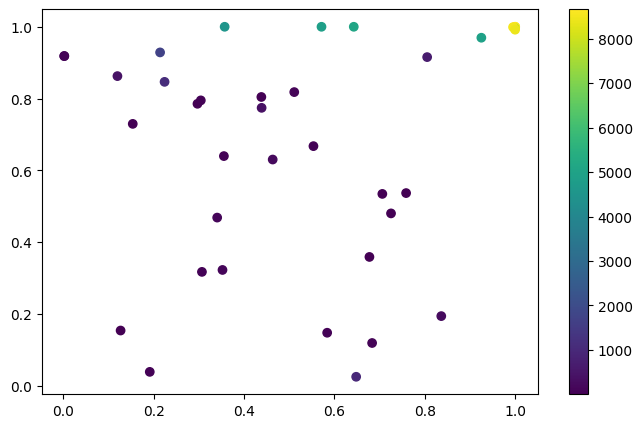

In [8]:
fig, ax = plt.subplots()
fig.set_figheight(5)
fig.set_figwidth(8)
plt.scatter(X[:, 0], X[:, 1], c = y)
plt.colorbar()

Text(0.5, 0.92, 'Scatter Plot of Contamination Sources Input Data Points with Output Variable y')

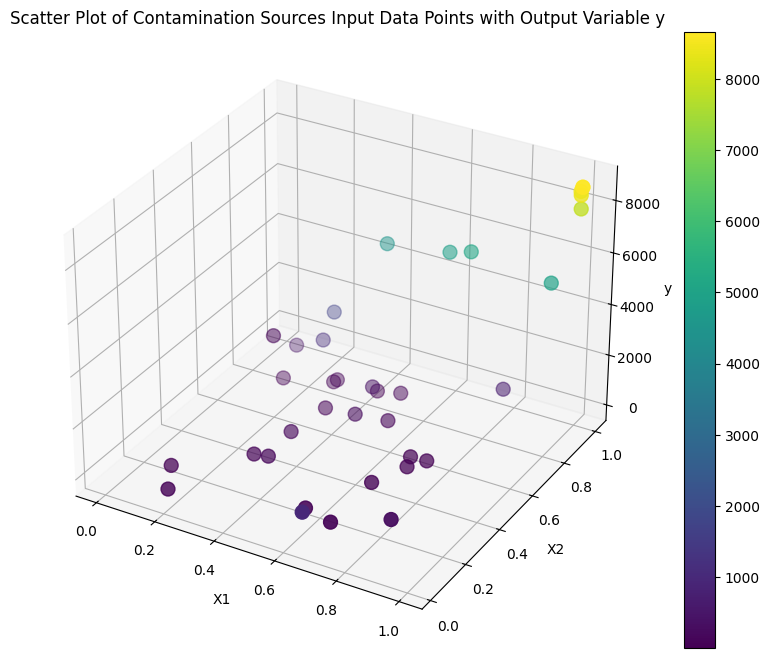

In [9]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X[:,0], X[:,1], y, c=y, cmap='viridis', s=100)

plt.colorbar(sc)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('y')

ax.set_title('Scatter Plot of Contamination Sources Input Data Points with Output Variable y')


**Acquisition Functions**

In [10]:
#UCB is useful when you want a balance between exploring new areas of the search space (high uncertainty) and exploiting known areas 
#with high mean values. The parameter β controls this balance. It's a good general-purpose acquisition function for many optimization problems.
def upper_confidence_bound(post_mean, post_std, beta):
    ucb = post_mean + beta * post_std # upper confidence bpon (ucb) = mu + kappa * sigma 
    print("\n\nUCB Shape: ", np.shape(ucb))
    return ucb


#PI is more focused on exploitation, as it prioritizes areas where the predicted mean is higher than the current best observed value (ymax)
#Use PI when you have a well-calibrated model and you want to focus on improving the best observed value.
def probability_of_improvement(post_mean, post_std, y_max):
    # Calculate the improvement
    improvement = post_mean - y_max
    
    # Calculate the Z value
    Z = improvement / post_std
    
    # Calculate the probability of improvement using the cumulative distribution function (CDF) of the normal distribution
    PI = norm.cdf(Z)
    print("\n\nPI Shape: ", np.shape(PI))
    return PI


def probability_of_improvement_with_exploration_term(post_mean, post_std, y_max, epsilon):
    # Calculate the improvement with exploration term
    improvement = post_mean - (y_max + epsilon)
    
    # Calculate the Z value
    Z = improvement / post_std
    
    # Calculate the probability of improvement using the cumulative distribution function (CDF) of the normal distribution
    PI = norm.cdf(Z)
    print("\n\nPI With Exploitation Term Shape: ", np.shape(PI))
    return PI


#EI provides a balance between exploration and exploitation, similar to UCB, but it also considers the magnitude of improvement.
#Use EI when you want to maximize the expected improvement over the current best observed value.
def expected_improvement(post_mean, post_std, y_max):
    # Calculate the improvement
    improvement = post_mean - y_max
    
    # Calculate the Z value
    Z = improvement / post_std
    
    # Calculate the expected improvement
    EI = improvement * norm.cdf(Z) + post_std * norm.pdf(Z)
    print("\n\nEI Shape: ", np.shape(EI))
    return EI

#Thompson Sampling is useful when you want to sample from the posterior distribution of the model, which inherently balances exploration and exploitation.
#Use Thompson Sampling when you want a stochastic approach to selecting the next point.
def thompson_sampling(post_mean, post_std):
    # Sample from the posterior distribution
    samples = np.random.normal(post_mean, post_std)
    print("\n\nThompson Samples Shape: ", np.shape(samples))
    return samples

**Input Sampling Methods**

In [11]:
def exploration_grid():
    x1_grid = np.linspace(0.000001, 0.999999, 10)
    x2_grid = np.linspace(0.000001, 0.999999, 10)
    x3_grid = np.linspace(0.000001, 0.999999, 10)
    x4_grid = np.linspace(0.000001, 0.999999, 10)

    x1_grid, x2_grid, x3_grid, x4_grid = np.meshgrid(x1_grid, x2_grid, x3_grid, x4_grid)    
    x_grid = np.vstack([x1_grid.ravel(), x2_grid.ravel(), x3_grid.ravel(),  x4_grid.ravel()]).T

    return x_grid

def exploitation_grid(center, delta=0.05):
    """
    Create a grid for exploitation around the given center point (array of 4 values).
    delta: half-width of the interval to explore around each coordinate.
    """
    x1, x2, x3, x4 = center
    x1_grid = np.linspace(max(0.000001, x1 - delta), min(0.999999, x1 + delta), 10)
    x2_grid = np.linspace(max(0.000001, x2 - delta), min(0.999999, x2 + delta), 10)
    x3_grid = np.linspace(max(0.000001, x3 - delta), min(0.999999, x3 + delta), 10)
    x4_grid = np.linspace(max(0.000001, x4 - delta), min(0.999999, x4 + delta), 10)

    x1_grid, x2_grid, x3_grid, x4_grid = np.meshgrid(x1_grid, x2_grid, x3_grid, x4_grid)    
    x_grid = np.vstack([x1_grid.ravel(), x2_grid.ravel(), x3_grid.ravel(), x4_grid.ravel()]).T

    return x_grid

def exploration_latin_hypercube():
    """
    Create a Latin Hypercube sample for exploration.
    """
    from scipy.stats import qmc
    n_samples = 10000
    bounds = [
        (0.000001, 0.999999),  # x1
        (0.000001, 0.999999),  # x2
        (0.000001, 0.999999),  # x3
        (0.000001, 0.999999)   # x4
    ]
    sampler = qmc.LatinHypercube(d=4)
    lhs_sample = sampler.random(n=n_samples)
    l_bounds = np.array([b[0] for b in bounds])
    u_bounds = np.array([b[1] for b in bounds])
    lhs_samples = qmc.scale(lhs_sample, l_bounds, u_bounds)
    return lhs_samples

def exploitation_latin_hypercube(center, delta=0.05):
    """
    Create a Latin Hypercube sample for exploitation around the given center point (array of 4 values).
    delta: half-width of the interval to explore around each coordinate.
    """
    from scipy.stats import qmc
    n_samples = 10000
    bounds = [
        (max(0.000001, center[0] - delta), min(0.999999, center[0] + delta)),  # x1
        (max(0.000001, center[1] - delta), min(0.999999, center[1] + delta)),  # x2
        (max(0.000001, center[2] - delta), min(0.999999, center[2] + delta)),  # x3
        (max(0.000001, center[3] - delta), min(0.999999, center[3] + delta))   # x4
    ]
    sampler = qmc.LatinHypercube(d=4)
    lhs_sample = sampler.random(n=n_samples)
    l_bounds = np.array([b[0] for b in bounds])
    u_bounds = np.array([b[1] for b in bounds])
    lhs_samples = qmc.scale(lhs_sample, l_bounds, u_bounds)
    return lhs_samples

In [12]:
def query_black_box_function_with_default_kernel(X, y, x_grid, acquisition_func):
    
    beta = 1.96
    model = GaussianProcessRegressor()
    model.fit(X, y)
       
    post_mean, post_std = model.predict(x_grid, return_std=True) #post_mean is y_pred and post_std is sigma i.e. s
    #acquisition_function = post_mean + beta * post_std # upper confidence bound (ucb) = mu + kappa * sigma mu + kappa * sigma 
    if acquisition_func == upper_confidence_bound:
        acquisition_function = acquisition_func(post_mean, post_std, beta)
        
    elif acquisition_func == probability_of_improvement:
        y_max = np.max(y)  # Define y_max as the maximum observed value
        acquisition_function = acquisition_func(post_mean, post_std, y_max)
        
    elif acquisition_func == probability_of_improvement_with_exploration_term:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max, 0.8)

    elif acquisition_func == expected_improvement:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max)

    else: #thompson_sampling
         acquisition_function = acquisition_func(post_mean, post_std)
    
    next_query = x_grid[np.argmax(acquisition_function)]
    y_pred = post_mean[np.argmax(acquisition_function)]
    
    next_query = next_query.reshape(1,4)
    y_pred = np.array([y_pred])
    
    print(f"Query to Black Box Function Maximizes at Input: ({next_query[0][0]:.6f}-{next_query[0][1]:.6f}-{next_query[0][2]:.6f}-{next_query[0][3]:.6f})")
    print(f"Predicted Value at ({next_query[0][0]:.6f}-{next_query[0][1]:.6f}-{next_query[0][2]:.6f}-{next_query[0][3]:.6f}) is {y_pred[0]})") 
    print("Index of maximum acquisition function value: ", np.argmax(acquisition_function))
   
    return next_query, y_pred

In [13]:
def next_query_with_default_kernel(X, y, x_grid):
    x_random = np.random.uniform(size = 2)
    print(f"Random Query: {x_random[0]:.6f}-{x_random[1]:.6f}")

    x_ucb, y_pred_ucb = query_black_box_function_with_default_kernel(X, y, x_grid, upper_confidence_bound)
    
    x_pi, y_pred_pi = query_black_box_function_with_default_kernel(X, y, x_grid, probability_of_improvement)
    
    x_piet, y_pred_piet = query_black_box_function_with_default_kernel(X, y, x_grid, probability_of_improvement_with_exploration_term)
    
    x_ei, y_pred_ei = query_black_box_function_with_default_kernel(X, y, x_grid, expected_improvement)
    
    x_ts, y_pred_ts = query_black_box_function_with_default_kernel(X, y, x_grid, thompson_sampling)

    return x_ucb, y_pred_ucb, x_pi, y_pred_pi, x_piet, y_pred_piet, x_ei, y_pred_ei, x_ts, y_pred_ts

**Exploration**

Explore the whole space with **defalut** RBF Kernel

In [14]:
x_ucb, y_pred_ucb, x_pi, y_pred_pi, x_piet, y_pred_piet, x_ei, y_pred_ei, x_ts, y_pred_ts = next_query_with_default_kernel(X, y, exploration_grid())

Random Query: 0.710934-0.186772


UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.999999-0.000001-0.999999)
Predicted Value at (0.999999-0.999999-0.000001-0.999999) is 13135.036994761533)
Index of maximum acquisition function value:  9909


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.888888-0.888888-0.000001-0.999999)
Predicted Value at (0.888888-0.888888-0.000001-0.999999) is 8938.407266755623)
Index of maximum acquisition function value:  8809


PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.888888-0.888888-0.000001-0.999999)
Predicted Value at (0.888888-0.888888-0.000001-0.999999) is 8938.407266755623)
Index of maximum acquisition function value:  8809


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.999999-0.000001-0.999999)
Predicted Value at (0.999999-0.999999-0.000001-0.999999) is 13135.036994761533)
Index of maximum acquisition function val

**Exploitation**

In [15]:
best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far: 8662.405001248297
Best query so far: [0.999999 0.999999 0.999999 0.999999]


In [16]:
x_ucb, y_pred_ucb, x_pi, y_pred_pi, x_piet, y_pred_piet, x_ei, y_pred_ei, x_ts, y_pred_ts = next_query_with_default_kernel(X, y, exploitation_grid(best_query_so_far))

Random Query: 0.401708-0.317628


UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.999999-0.999999-0.999999)
Predicted Value at (0.999999-0.999999-0.999999-0.999999) is 8662.318864425511)
Index of maximum acquisition function value:  9999


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.949999-0.949999-0.949999-0.949999)
Predicted Value at (0.949999-0.949999-0.949999-0.949999) is 5293.921360509503)
Index of maximum acquisition function value:  0


PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.949999-0.949999-0.949999-0.949999)
Predicted Value at (0.949999-0.949999-0.949999-0.949999) is 5293.921360509503)
Index of maximum acquisition function value:  0


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.949999-0.949999-0.949999-0.949999)
Predicted Value at (0.949999-0.949999-0.949999-0.949999) is 5293.921360509503)
Index of maximum acquisition function value:  0



**Hyperparameter Tuning using gp_minimize**

In [17]:
from sklearn.gaussian_process.kernels import Matern, RationalQuadratic, DotProduct
def query_black_box_function_with_hyper_parameters(X, y, x_grid, acquisition_func, kernel_type, rbf_lengthscale, noise_assumption, restarts, beta):
    # Define the kernel based on the kernel_type parameter
    if kernel_type == 'RBF':
        kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds=(1e-2, 1e2)) * C(1.0, (1e-10, 1e10))

    elif kernel_type == 'Matern':
        kernel = Matern(length_scale=rbf_lengthscale, length_scale_bounds=(1e-2, 1e2), nu=1.5)

    elif kernel_type == 'RationalQuadratic':
        kernel = RationalQuadratic(length_scale=rbf_lengthscale, alpha=1.0) * C(1.0, (1e-10, 1e10))
      
    elif kernel_type == 'DotProduct':
        kernel = DotProduct(sigma_0=1.0, sigma_0_bounds=(1e-3, 1e3)) + C(1.0, (1e-10, 1e10))
    else:
        kernel = None

    # Create and fit the Gaussian Process model
    if kernel is None:
        model = GaussianProcessRegressor()
    else:   
        model = GaussianProcessRegressor(kernel=kernel, alpha=noise_assumption, n_restarts_optimizer=restarts)

    model.fit(X, y)

    # Predict the mean and standard deviation
    post_mean, post_std = model.predict(x_grid, return_std=True)

    # Compute the acquisition function
    if acquisition_func == upper_confidence_bound:
        acquisition_function = acquisition_func(post_mean, post_std, beta)
    elif acquisition_func == probability_of_improvement:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max)
    elif acquisition_func == probability_of_improvement_with_exploration_term:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max, 0.8)
    elif acquisition_func == expected_improvement:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max)
    else:  # thompson_sampling
        acquisition_function = acquisition_func(post_mean, post_std)

    # Find the point that maximizes the acquisition function
    next_query = x_grid[np.argmax(acquisition_function)]
    y_pred = post_mean[np.argmax(acquisition_function)]

    next_query = next_query.reshape(1, 4)
    y_pred = np.array([y_pred])

    print(f"Query to Black Box Function Maximizes at Input: ({next_query[0][0]:.6f}-{next_query[0][1]:.6f}-{next_query[0][2]:.6f}-{next_query[0][3]:.6f})")
    print(f"Predicted Value at ({next_query[0][0]:.6f}-{next_query[0][1]:.6f}-{next_query[0][2]:.6f}-{next_query[0][3]:.6f}) is {y_pred[0]})") 
    print("Index of maximum acquisition function value: ", np.argmax(acquisition_function))
    print("Kernel Type:", kernel_type)

    return next_query, y_pred

**Hyperparameter Tuning using gp_minimize**

With Full Grid as Search Space

In [18]:
# Install scikit-optimize if not already installed
%pip install scikit-optimize

from skopt import gp_minimize
from skopt.space import Real, Integer, Categorical
from skopt.utils import use_named_args

x_grid = exploration_grid()


# Define the search space
search_space = [
    Real(0.01, 1.0, name='lengthscale'),
    Real(1e-10, 1e-1, name='noise_assumption'),
    Integer(0, 15, name='restarts'),
    Real(1.0, 3.0, name='beta'),
    Categorical([upper_confidence_bound, probability_of_improvement, 
                 probability_of_improvement_with_exploration_term, 
                 expected_improvement, thompson_sampling], name='acquisition_func'),
    Categorical(['None', 'RBF', 'Matern', 'RationalQuadratic', 'DotProduct'], name='kernel_type')
]

# Define the objective function
@use_named_args(search_space)
def objective_function_gp(lengthscale, noise_assumption, restarts, beta, acquisition_func, kernel_type):
    global best_x_ucb, best_y_pred_ucb, best_params

    next_query, y_pred = query_black_box_function_with_hyper_parameters(
        X, y, x_grid,
        acquisition_func=acquisition_func,
        kernel_type=kernel_type,
        rbf_lengthscale=lengthscale,
        noise_assumption=noise_assumption,
        restarts=restarts,
        beta=beta
    )
    
    # Return the negative of the prediction as we want to maximize y_pred
    return -y_pred[0]

# Perform Bayesian optimization
result = gp_minimize(
    func=objective_function_gp,
    dimensions=search_space,
    n_calls=100,  # Number of evaluations
    random_state=42
)

# Extract the best parameters
(best_rbf_lengthscale, best_noise_assumption, best_restarts, 
 best_beta, best_acquisition_func, best_kernel_type) = result.x
print(f"Best Parameters: rbf_lengthscale={best_rbf_lengthscale}, noise_assumption={best_noise_assumption}, "
      f"restarts={best_restarts}, beta={best_beta}, acquisition_func={best_acquisition_func.__name__}, "
      f"kernel_type={best_kernel_type}")

# Use the best parameters to query the black-box function
next_query, y_pred = query_black_box_function_with_hyper_parameters(
    X, y, x_grid,
    acquisition_func=best_acquisition_func,
    kernel_type=best_kernel_type,
    rbf_lengthscale=best_rbf_lengthscale, 
    noise_assumption=best_noise_assumption,
    restarts=best_restarts,
    beta=best_beta
)

next_query, y_pred

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\harji\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip




PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.888888-0.888888-0.000001-0.999999)
Predicted Value at (0.888888-0.888888-0.000001-0.999999) is 8938.407266755623)
Index of maximum acquisition function value:  8809
Kernel Type: None


UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.999999-0.999999-0.999999)
Predicted Value at (0.999999-0.999999-0.999999-0.999999) is 8662.404987922795)
Index of maximum acquisition function value:  9999
Kernel Type: RationalQuadratic


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.999999-0.000001-0.999999)
Predicted Value at (0.999999-0.999999-0.000001-0.999999) is 13135.036994761533)
Index of maximum acquisition function value:  9909
Kernel Type: None


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(




Thompson Samples Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.999999-0.999999-0.999999)
Predicted Value at (0.999999-0.999999-0.999999-0.999999) is 8662.40262276999)
Index of maximum acquisition function value:  9999
Kernel Type: RBF


...

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified upper bound 10000000000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_proce



PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001-0.000001-0.000001)
Predicted Value at (0.000001-0.000001-0.000001-0.000001) is -5394.888131015177)
Index of maximum acquisition function value:  0
Kernel Type: DotProduct


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__sigma_0 is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(




Thompson Samples Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.999999-0.999999-0.999999)
Predicted Value at (0.999999-0.999999-0.999999-0.999999) is 6617.768409236854)
Index of maximum acquisition function value:  9999
Kernel Type: DotProduct


PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.888888-0.888888-0.000001-0.999999)
Predicted Value at (0.888888-0.888888-0.000001-0.999999) is 8938.407266755623)
Index of maximum acquisition function value:  8809
Kernel Type: None


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.999999-0.000001-0.999999)
Predicted Value at (0.999999-0.999999-0.000001-0.999999) is 13135.036994761533)
Index of maximum acquisition function value:  9909
Kernel Type: None


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.999999-0.000001-0.999999)
Predicted Value at (0.999999-0.999999-0.000001-0.999999) is 13135.036994761533)


(array([[9.99999e-01, 9.99999e-01, 1.00000e-06, 9.99999e-01]]),
 array([13135.03699476]))

**Exploration**

Explore the whole grid as search space with Best Hyperparameters found using **gp_minimize**

In [19]:
next_query, y_pred = query_black_box_function_with_hyper_parameters(X, y, exploration_grid(),
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)

next_query, y_pred



EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.999999-0.000001-0.999999)
Predicted Value at (0.999999-0.999999-0.000001-0.999999) is 13135.036994761533)
Index of maximum acquisition function value:  9909
Kernel Type: None


(array([[9.99999e-01, 9.99999e-01, 1.00000e-06, 9.99999e-01]]),
 array([13135.03699476]))

**Exploitation**

Exploit around the inputs as shown in the output of next cell with Best Hyperparameters found using **gp_minimize**

In [20]:
best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far: 8662.405001248297
Best query so far: [0.999999 0.999999 0.999999 0.999999]


In [21]:
next_query, y_pred = query_black_box_function_with_hyper_parameters(X, y, exploitation_grid(best_query_so_far),
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)
next_query, y_pred



EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.949999-0.949999-0.949999-0.949999)
Predicted Value at (0.949999-0.949999-0.949999-0.949999) is 5293.921360509503)
Index of maximum acquisition function value:  0
Kernel Type: None


(array([[0.949999, 0.949999, 0.949999, 0.949999]]), array([5293.92136051]))

**Hyperparameter Tuning with BayesianOptimization**

With Full Grid as Search Space

In [22]:
%pip install bayesian-optimization
from bayes_opt import BayesianOptimization

x_grid = exploration_grid()

# Define the function to optimize
def objective_function_bo(lengthscale, noise_assumption, restarts, beta, kernel_type, acquisition_func):
    # Map integer values to kernel types and acquisition functions
    kernel_types = ['None', 'RBF', 'Matern', 'RationalQuadratic', 'DotProduct']
    acquisition_funcs = [
        upper_confidence_bound,
        probability_of_improvement,
        probability_of_improvement_with_exploration_term,
        expected_improvement,
        thompson_sampling
    ]
    kernel_type_str = kernel_types[int(round(kernel_type))]
    acquisition_func_obj = acquisition_funcs[int(round(acquisition_func))]

    next_query, y_pred = query_black_box_function_with_hyper_parameters(
        X, y, x_grid,
        acquisition_func=acquisition_func_obj,
        kernel_type=kernel_type_str,
        rbf_lengthscale=lengthscale,
        noise_assumption=noise_assumption,
        restarts=int(round(restarts)),
        beta=beta
    )
    # Return the negative of the prediction as we want to maximize y_pred
    return y_pred[0]

# Define the bounds for each parameter
pbounds = {
    'lengthscale': (0.01, 1.0),
    'noise_assumption': (1e-10, 1e-1),
    'restarts': (0, 15),
    'beta': (1.0, 3.0),
    'kernel_type': (0, 4),  # 0:None, 1: RBF, 2: Matern, 3: RationalQuadratic, 4: DotProduct
    'acquisition_func': (0, 4)  # 0: UCB, 1: PI, 2: PI+explore, 3: EI, 4: Thompson
}

optimizer = BayesianOptimization(
    f=objective_function_bo,
    pbounds=pbounds,
    random_state=42,
    verbose=2
)

optimizer.maximize(
    init_points=5,
    n_iter=100
)

# Extract the best parameters
best_params = optimizer.max['params']
best_rbf_lengthscale = best_params['lengthscale']
best_noise_assumption = best_params['noise_assumption']
best_restarts = int(round(best_params['restarts']))
best_beta = best_params['beta']
best_kernel_type = ['None', 'RBF', 'Matern', 'RationalQuadratic', 'DotProduct'][int(round(best_params['kernel_type']))]
best_acquisition_func = [
    upper_confidence_bound,
    probability_of_improvement,
    probability_of_improvement_with_exploration_term,
    expected_improvement,
    thompson_sampling
][int(round(best_params['acquisition_func']))]

print(f"Best Parameters: rbf_lengthscale={best_rbf_lengthscale}, noise_assumption={best_noise_assumption}, "
      f"restarts={best_restarts}, beta={best_beta}, kernel_type={best_kernel_type}, "
      f"acquisition_func={best_acquisition_func.__name__}")

# Use the best parameters to query the black-box function
next_query, y_pred = query_black_box_function_with_hyper_parameters(
    X, y, x_grid,
    acquisition_func=best_acquisition_func,
    kernel_type=best_kernel_type,
    rbf_lengthscale=best_rbf_lengthscale,
    noise_assumption=best_noise_assumption,
    restarts=best_restarts,
    beta=best_beta
)

next_query, y_pred



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\harji\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
|   iter    |  target   | acquis... |   beta    | kernel... | length... | noise_... | restarts  |
-------------------------------------------------------------------------------------------------


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.999999-0.999999-0.999999)
Predicted Value at (0.999999-0.999999-0.999999-0.999999) is 8662.4045083921)
Index of maximum acquisition function value:  9999
Kernel Type: RationalQuadratic
| 1         | 8.662e+03 | 1.498     | 2.901     | 2.928     | 0.6027    | 0.0156    | 2.34      |


UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.999999-0.999999-0.999999)
Predicted Value at (0.999999-0.999999-0.999999-0.999999) is 8609.264054696214)
Index of maximum acquisition function value:  9999
Kernel Type: Matern
| 2         | 8.609e+03 | 0.2323    

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__sigma_0 is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:



EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001-0.000001-0.000001)
Predicted Value at (0.000001-0.000001-0.000001-0.000001) is -5355.350338101243)
Index of maximum acquisition function value:  0
Kernel Type: DotProduct
| 9         | -5.355e+0 | 3.158     | 2.071     | 3.579     | 0.4628    | 0.04225   | 9.807     |


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.999999-0.999999-0.999999)
Predicted Value at (0.999999-0.999999-0.999999-0.999999) is 8662.403652391638)
Index of maximum acquisition function value:  9999
Kernel Type: RationalQuadratic
| 10        | 8.662e+03 | 0.6007    | 2.377     | 3.051     | 0.4341    | 0.0427    | 13.26     |


UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.999999-0.999999-0.999999)
Predicted Value at (0.999999-0.999999-0.999999-0.999999) is 8662.404762895929)
Index of maximum acquisition function value:  9999
Kernel Type: RationalQuadratic
| 11 

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__sigma_0 is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:

...

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)




UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.999999-0.999999-0.999999)
Predicted Value at (0.999999-0.999999-0.999999-0.999999) is 8662.404996174631)
Index of maximum acquisition function value:  9999
Kernel Type: Matern
| 40        | 8.662e+03 | 0.09747   | 1.526     | 1.819     | 1.0       | 1e-10     | 13.78     |


UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.999999-0.999999-0.999999)
Predicted Value at (0.999999-0.999999-0.999999-0.999999) is 8662.40493391015)
Index of maximum acquisition function value:  9999
Kernel Type: RBF
| 41        | 8.662e+03 | 0.4861    | 2.044     | 1.074     | 0.2646    | 1e-10     | 13.53     |


UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.999999-0.999999-0.999999)
Predicted Value at (0.999999-0.999999-0.999999-0.999999) is 8662.402853551874)
Index of maximum acquisition function value:  9999
Kernel Type: RationalQuadratic
| 42        | 8.662e

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\_gpr.py:478: UserWarning: Predicted variances smaller than 0. Setting those variances to 0.
  warnings.warn(
C:\Users\harji\AppData\Local\Temp\ipykernel_29768\3886067424.py:16: RuntimeWarning: divide by zero encountered in divide
  Z = improvement / post_std




PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.999999-0.888888-0.999999)
Predicted Value at (0.999999-0.999999-0.888888-0.999999) is 7034.290873990366)
Index of maximum acquisition function value:  9989
Kernel Type: RBF
| 50        | 7.034e+03 | 0.7318    | 1.0       | 1.08      | 0.9166    | 1e-10     | 14.34     |


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.999999-0.999999-0.999999)
Predicted Value at (0.999999-0.999999-0.999999-0.999999) is 8662.405001247822)
Index of maximum acquisition function value:  9999
Kernel Type: RationalQuadratic
| 51        | 8.662e+03 | 0.6334    | 3.0       | 3.224     | 1.0       | 1e-10     | 12.13     |


UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.999999-0.999999-0.999999)
Predicted Value at (0.999999-0.999999-0.999999-0.999999) is 6643.444635000114)
Index of maximum acquisition function value:  9999
Kernel Type: DotProduct
| 52        | 6.6

(array([[9.99999e-01, 9.99999e-01, 1.00000e-06, 9.99999e-01]]),
 array([13135.03699476]))

**Exploration**

Explore the whole grid as search space with Best Hyperparameters found using **BayesianOptimization**

In [23]:
next_query, y_pred = query_black_box_function_with_hyper_parameters(X, y, exploration_grid(),
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)

next_query, y_pred



Thompson Samples Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.999999-0.000001-0.999999)
Predicted Value at (0.999999-0.999999-0.000001-0.999999) is 13135.036994761533)
Index of maximum acquisition function value:  9909
Kernel Type: None


(array([[9.99999e-01, 9.99999e-01, 1.00000e-06, 9.99999e-01]]),
 array([13135.03699476]))

**Exploitation**

Exploit around the inputs as shown in the output of next cell with Best Hyperparameters found using **BayesianOptimization**

In [24]:
best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far: 8662.405001248297
Best query so far: [0.999999 0.999999 0.999999 0.999999]


In [25]:
next_query, y_pred = query_black_box_function_with_hyper_parameters(X, y, exploitation_grid(best_query_so_far),
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)
next_query, y_pred



Thompson Samples Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.999999-0.999999-0.999999)
Predicted Value at (0.999999-0.999999-0.999999-0.999999) is 8662.318864425511)
Index of maximum acquisition function value:  9999
Kernel Type: None


(array([[0.999999, 0.999999, 0.999999, 0.999999]]), array([8662.31886443]))

**Hyperparameter Tuning using BayesianOptimization]**

Latin Hypercube Sampling

In [26]:
%pip install bayesian-optimization
from bayes_opt import BayesianOptimization

lhs_samples = exploration_latin_hypercube()

# Define the function to optimize
def objective_function_bo_lhs(lengthscale, noise_assumption, restarts, beta, kernel_type, acquisition_func):
    # Map integer values to kernel types and acquisition functions
    kernel_types = ['None', 'RBF', 'Matern', 'RationalQuadratic', 'DotProduct']
    acquisition_funcs = [
        upper_confidence_bound,
        probability_of_improvement,
        probability_of_improvement_with_exploration_term,
        expected_improvement,
        thompson_sampling
    ]
    kernel_type_str = kernel_types[int(round(kernel_type))]
    acquisition_func_obj = acquisition_funcs[int(round(acquisition_func))]

    next_query, y_pred = query_black_box_function_with_hyper_parameters(
        X, y, lhs_samples,
        acquisition_func=acquisition_func_obj,
        kernel_type=kernel_type_str,
        rbf_lengthscale=lengthscale,
        noise_assumption=noise_assumption,
        restarts=int(round(restarts)),
        beta=beta
    )
    # Return the negative of the prediction as we want to maximize y_pred
    return y_pred[0]

# Define the bounds for each parameter
pbounds = {
    'lengthscale': (0.01, 1.0),
    'noise_assumption': (1e-10, 1e-1),
    'restarts': (0, 15),
    'beta': (1.0, 3.0),
    'kernel_type': (0, 4),  # 0:None, 1: RBF, 2: Matern, 3: RationalQuadratic, 4: DotProduct
    'acquisition_func': (0, 4)  # 0: UCB, 1: PI, 2: PI+explore, 3: EI, 4: Thompson
}

optimizer = BayesianOptimization(
    f=objective_function_bo_lhs,
    pbounds=pbounds,
    random_state=42,
    verbose=2
)

optimizer.maximize(
    init_points=5,
    n_iter=100
)

# Extract the best parameters
best_params = optimizer.max['params']
best_rbf_lengthscale = best_params['lengthscale']
best_noise_assumption = best_params['noise_assumption']
best_restarts = int(round(best_params['restarts']))
best_beta = best_params['beta']
best_kernel_type = ['None', 'RBF', 'Matern', 'RationalQuadratic', 'DotProduct'][int(round(best_params['kernel_type']))]
best_acquisition_func = [
    upper_confidence_bound,
    probability_of_improvement,
    probability_of_improvement_with_exploration_term,
    expected_improvement,
    thompson_sampling
][int(round(best_params['acquisition_func']))]

print(f"Best Parameters: rbf_lengthscale={best_rbf_lengthscale}, noise_assumption={best_noise_assumption}, "
      f"restarts={best_restarts}, beta={best_beta}, kernel_type={best_kernel_type}, "
      f"acquisition_func={best_acquisition_func.__name__}")

# Use the best parameters to query the black-box function
next_query, y_pred = query_black_box_function_with_hyper_parameters(
    X, y, lhs_samples,
    acquisition_func=best_acquisition_func,
    kernel_type=best_kernel_type,
    rbf_lengthscale=best_rbf_lengthscale,
    noise_assumption=best_noise_assumption,
    restarts=best_restarts,
    beta=best_beta
)

next_query, y_pred



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\harji\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
|   iter    |  target   | acquis... |   beta    | kernel... | length... | noise_... | restarts  |
-------------------------------------------------------------------------------------------------


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.949156-0.983669-0.642303-0.992259)
Predicted Value at (0.949156-0.983669-0.642303-0.992259) is 3721.2922965910993)
Index of maximum acquisition function value:  3412
Kernel Type: RationalQuadratic
| 1         | 3.721e+03 | 1.498     | 2.901     | 2.928     | 0.6027    | 0.0156    | 2.34      |


UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.949458-0.957002-0.947498-0.958677)
Predicted Value at (0.949458-0.957002-0.947498-0.958677) is 6131.069227501553)
Index of maximum acquisition function value:  7662
Kernel Type: Matern
| 2         | 6.131e+03 | 0.2323 

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)




EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.193599-0.076664-0.055978-0.615073)
Predicted Value at (0.193599-0.076664-0.055978-0.615073) is -3174.1589283204717)
Index of maximum acquisition function value:  0
Kernel Type: DotProduct
| 9         | -3.174e+0 | 3.158     | 2.071     | 3.579     | 0.4628    | 0.04225   | 9.807     |


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.949156-0.983669-0.642303-0.992259)
Predicted Value at (0.949156-0.983669-0.642303-0.992259) is 3721.312334322199)
Index of maximum acquisition function value:  3412
Kernel Type: RationalQuadratic
| 10        | 3.721e+03 | 0.6007    | 2.377     | 3.051     | 0.4341    | 0.0427    | 13.26     |


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.193599-0.076664-0.055978-0.615073)
Predicted Value at (0.193599-0.076664-0.055978-0.615073) is 39.2386413065048)
Index of maximum acquisition function value:  0
Kernel Type: Matern
| 11        | 39.24 

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


...

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__sigma_0 is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified upper bound 10000000000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(




PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.997401-0.891659-0.229490-0.946676)
Predicted Value at (0.997401-0.891659-0.229490-0.946676) is 8891.59064776887)
Index of maximum acquisition function value:  95
Kernel Type: None
| 73        | 8.892e+03 | 2.485     | 2.823     | 0.1534    | 0.4945    | 0.02727   | 10.94     |


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.926751-0.937419-0.044648-0.986498)
Predicted Value at (0.926751-0.937419-0.044648-0.986498) is 10307.524757894847)
Index of maximum acquisition function value:  3461
Kernel Type: None
| 74        | 1.031e+04 | 2.945     | 1.854     | 0.07574   | 0.06673   | 0.05737   | 10.52     |


Thompson Samples Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.877507-0.853160-0.084574-0.756793)
Predicted Value at (0.877507-0.853160-0.084574-0.756793) is -1.372672451402042)
Index of maximum acquisition function value:  6083
Kernel Type: RBF
|

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified upper bound 10000000000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(




EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.926751-0.937419-0.044648-0.986498)
Predicted Value at (0.926751-0.937419-0.044648-0.986498) is 10307.524757894847)
Index of maximum acquisition function value:  3461
Kernel Type: None
| 81        | 1.031e+04 | 2.867     | 1.415     | 0.01095   | 0.07523   | 0.02993   | 8.623     |


Thompson Samples Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.926751-0.937419-0.044648-0.986498)
Predicted Value at (0.926751-0.937419-0.044648-0.986498) is 10307.524757894847)
Index of maximum acquisition function value:  3461
Kernel Type: None
| 82        | 1.031e+04 | 3.659     | 2.563     | 0.05148   | 0.07954   | 0.06153   | 9.935     |


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.926751-0.937419-0.044648-0.986498)
Predicted Value at (0.926751-0.937419-0.044648-0.986498) is 10307.524757894847)
Index of maximum acquisition function value:  3461
Kernel Type: None
| 83        | 1.031

(array([[0.92675097, 0.93741897, 0.04464827, 0.98649815]]),
 array([10307.52475789]))

**Exploration**

Explore the Latin Hypescale search space with Best Hyperparameters found using **BaysianOptimization on Latin Hypescale Search Space**

In [27]:

next_query, y_pred = query_black_box_function_with_hyper_parameters(X, y, exploration_latin_hypercube(),
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)

next_query, y_pred



EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.808480-0.990742-0.002551-0.986604)
Predicted Value at (0.808480-0.990742-0.002551-0.986604) is 9847.949353977676)
Index of maximum acquisition function value:  5950
Kernel Type: None


(array([[0.80848037, 0.99074152, 0.00255093, 0.98660367]]),
 array([9847.94935398]))

**Exploitation**

Exploit around the inputs as shown in the output of next cell with Best Hyperparameters found using **BayesianOptimization on Latin Hypescale Search Space**

In [28]:
best_observation_so_far, best_query_so_far = best_observation(y)

Best observation so far: 8662.405001248297
Best query so far: [0.999999 0.999999 0.999999 0.999999]


In [29]:
next_query, y_pred = query_black_box_function_with_hyper_parameters(X, y, exploitation_latin_hypercube(best_query_so_far),
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)
next_query, y_pred



EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.986812-0.999761-0.966791-0.981708)
Predicted Value at (0.986812-0.999761-0.966791-0.981708) is 7508.864830178354)
Index of maximum acquisition function value:  0
Kernel Type: None


(array([[0.98681222, 0.99976115, 0.96679095, 0.98170847]]),
 array([7508.86483018]))